## **23CSE301 - Machine Learning - Activity 6- K Means Clustering**
### **CH.SC.U4CSE24142 - SANTHOSH**
### Date : 03/09/2026

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

In [4]:
# Load the dataset
data = pd.read_csv('10_K_Means_Clustering_Dataset_Exercise_1.csv')
print(data.shape)
data.head()

(272, 3)


,rownames,eruptions,waiting
0,1,3.600,79
1,2,1.800,54
2,3,3.333,74
3,4,2.283,62
4,5,4.533,85


In [5]:
# The dataset has 'rownames', 'eruptions', and 'waiting'. 
X = data[['eruptions', 'waiting']].values
print(f"Data shape after selecting features: {X.shape}")

Data shape after selecting features: (272, 2)


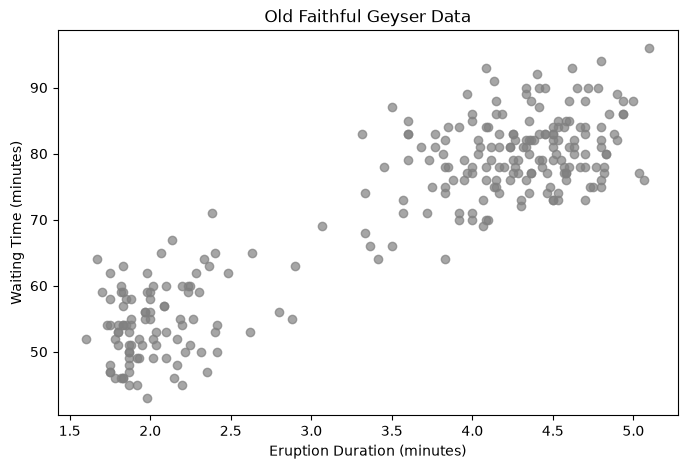

In [6]:
# Visualize the raw data before clustering
plt.figure(figsize=(8, 5))
plt.scatter(X[:, 0], X[:, 1], color='grey', alpha=0.7)
plt.title('Old Faithful Geyser Data')
plt.xlabel('Eruption Duration (minutes)')
plt.ylabel('Waiting Time (minutes)')
plt.show()

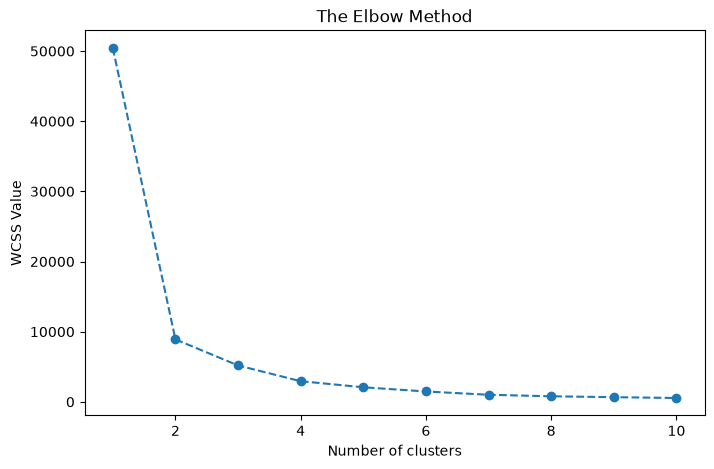

In [7]:
# Calculate WCSS (Within-Cluster Sum of Squares) for different number of clusters
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', n_init=10, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# Plot the Elbow graph
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS Value')
plt.show()

In [8]:
# Train the K-Means model on the dataset
kmeans = KMeans(n_clusters=2, init='k-means++', n_init=10, random_state=42)
y_kmeans = kmeans.fit_predict(X)

print("Cluster Centers:\n", kmeans.cluster_centers_)

Cluster Centers:
 [[ 4.29793023 80.28488372]
 [ 2.09433    54.75      ]]


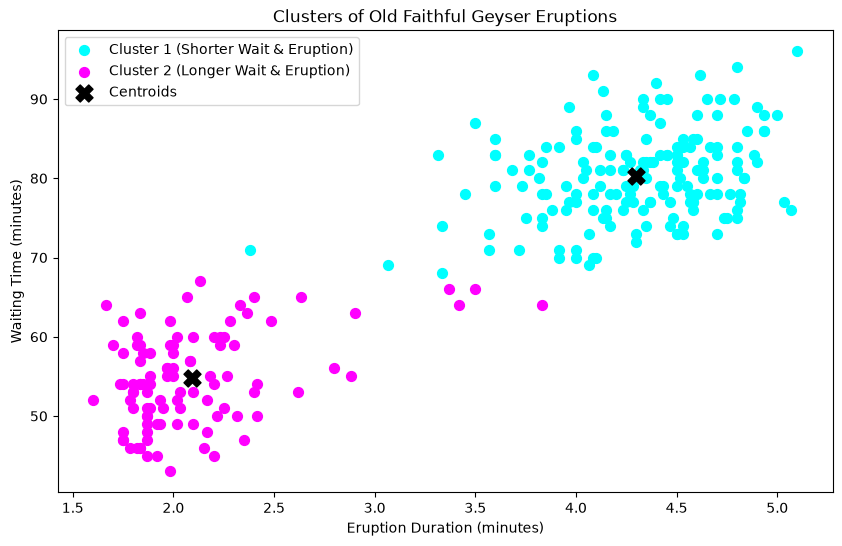

In [9]:
# Visualize the clusters
plt.figure(figsize=(10, 6))

# Plotting the data points belonging to each cluster
plt.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1], s=50, c='cyan', label='Cluster 1 (Shorter Wait & Eruption)')
plt.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], s=50, c='magenta', label='Cluster 2 (Longer Wait & Eruption)')

# Plotting the centroids
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=150, c='black', label='Centroids', marker='X')

plt.title('Clusters of Old Faithful Geyser Eruptions')
plt.xlabel('Eruption Duration (minutes)')
plt.ylabel('Waiting Time (minutes)')
plt.legend()
plt.show()